<a href="https://colab.research.google.com/github/sreelakshmisajeevan-854/Wine-Data-PCA-and-Clustering/blob/main/Wine-Data-PCA-and-Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Exploratory Data Analysis (EDA):

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/Datasets/wine.csv')

In [ ]:
df.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [ ]:
df.shape

(178, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [ ]:
df.isnull().sum()

,0
Type,0
Alcohol,0
Malic,0
Ash,0
Alcalinity,0
Magnesium,0
Phenols,0
Flavanoids,0
Nonflavanoids,0
Proanthocyanins,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


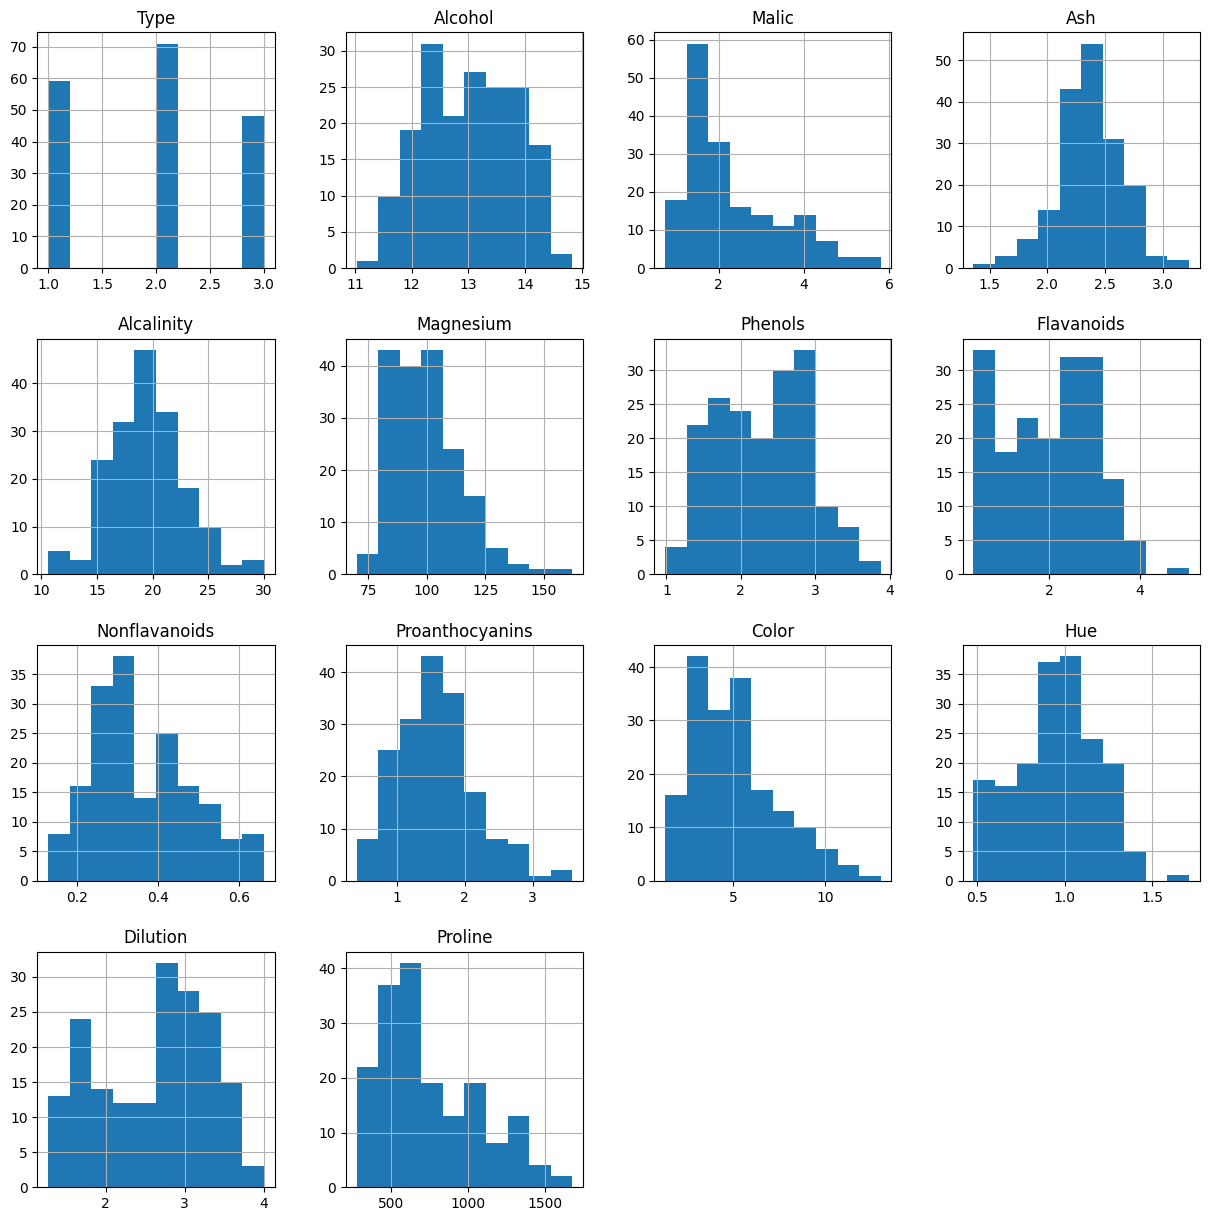

In [ ]:
df.hist(figsize=(15,15))
plt.show()

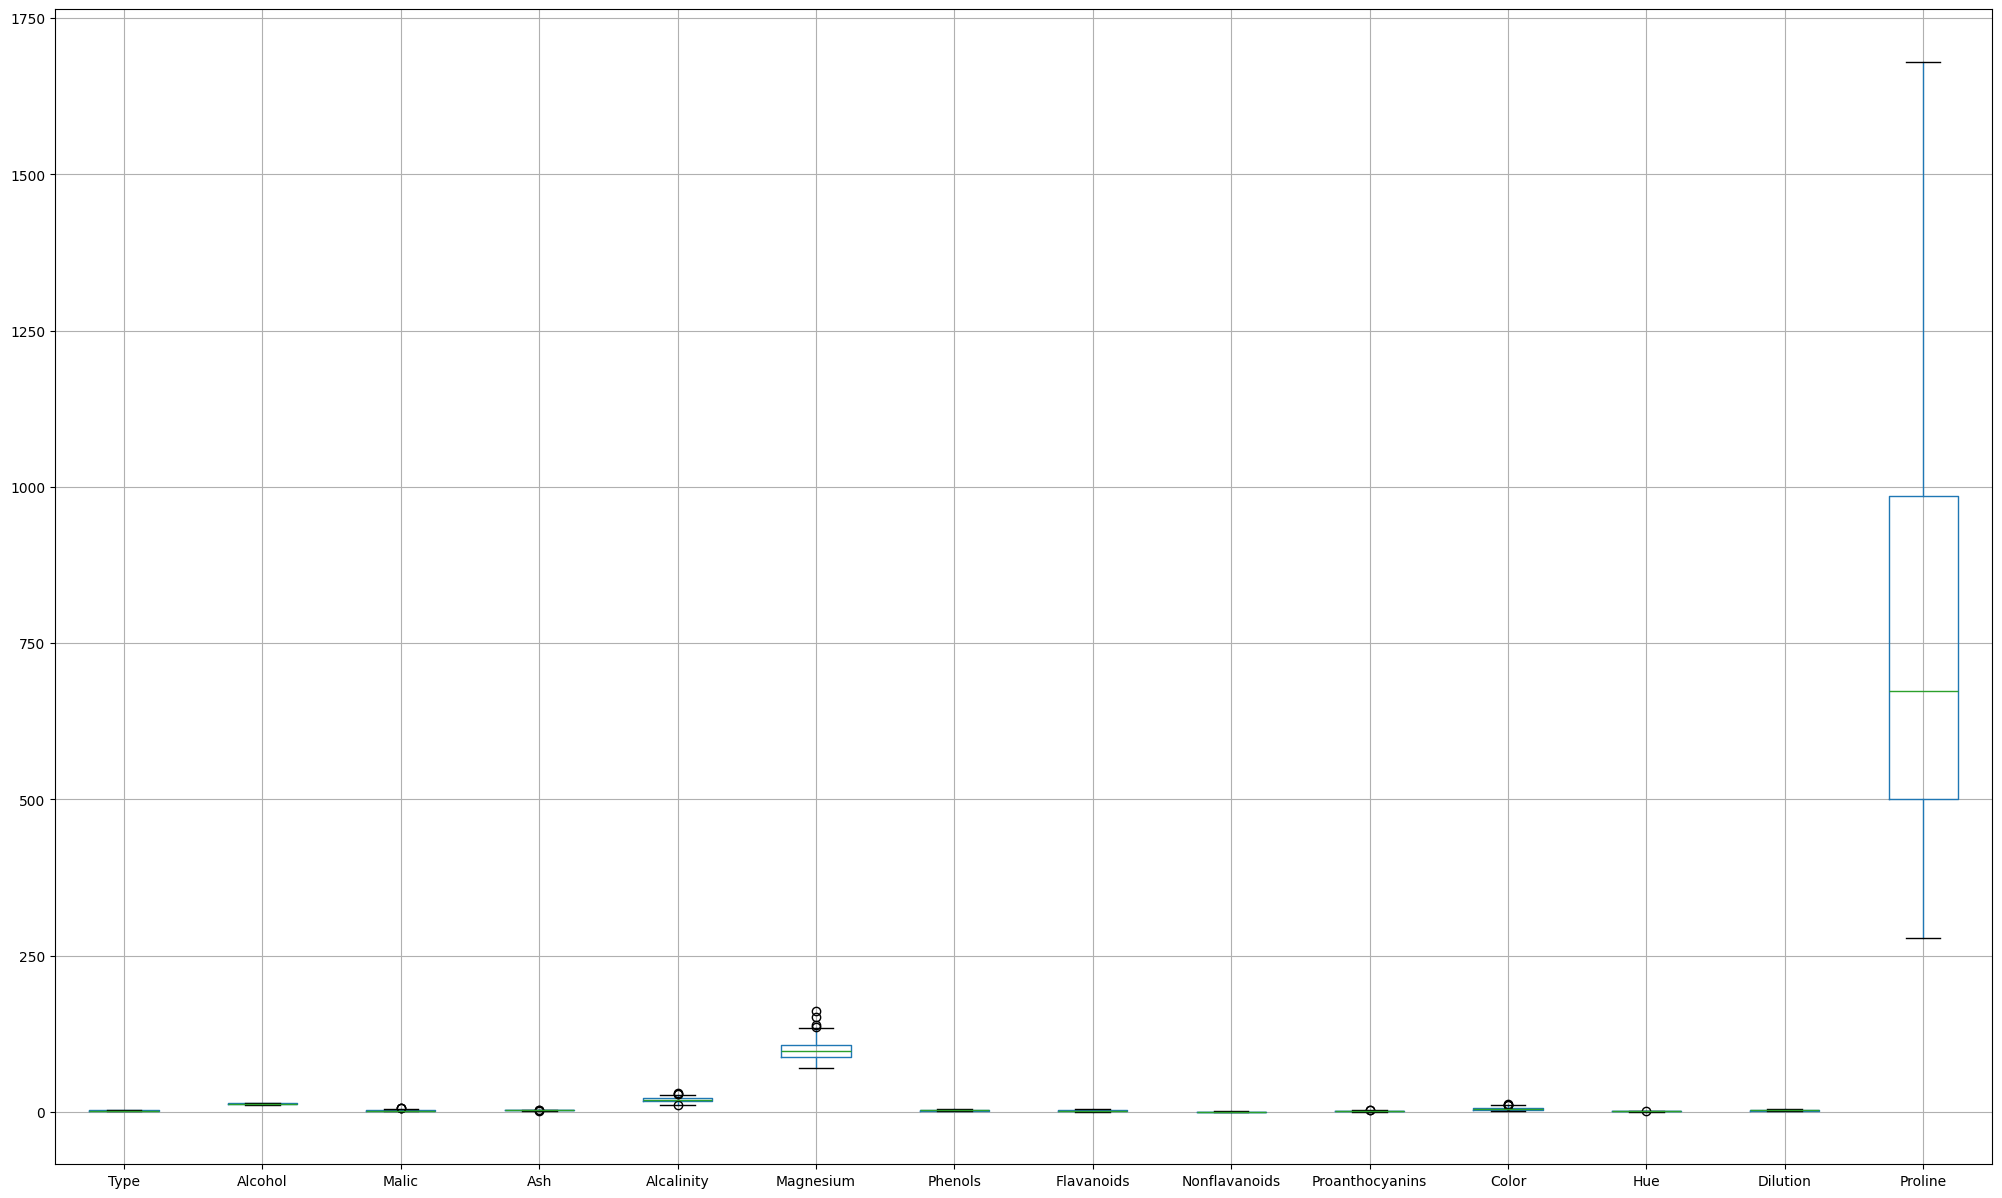

In [ ]:
df.boxplot(figsize=(25,15))
plt.show()

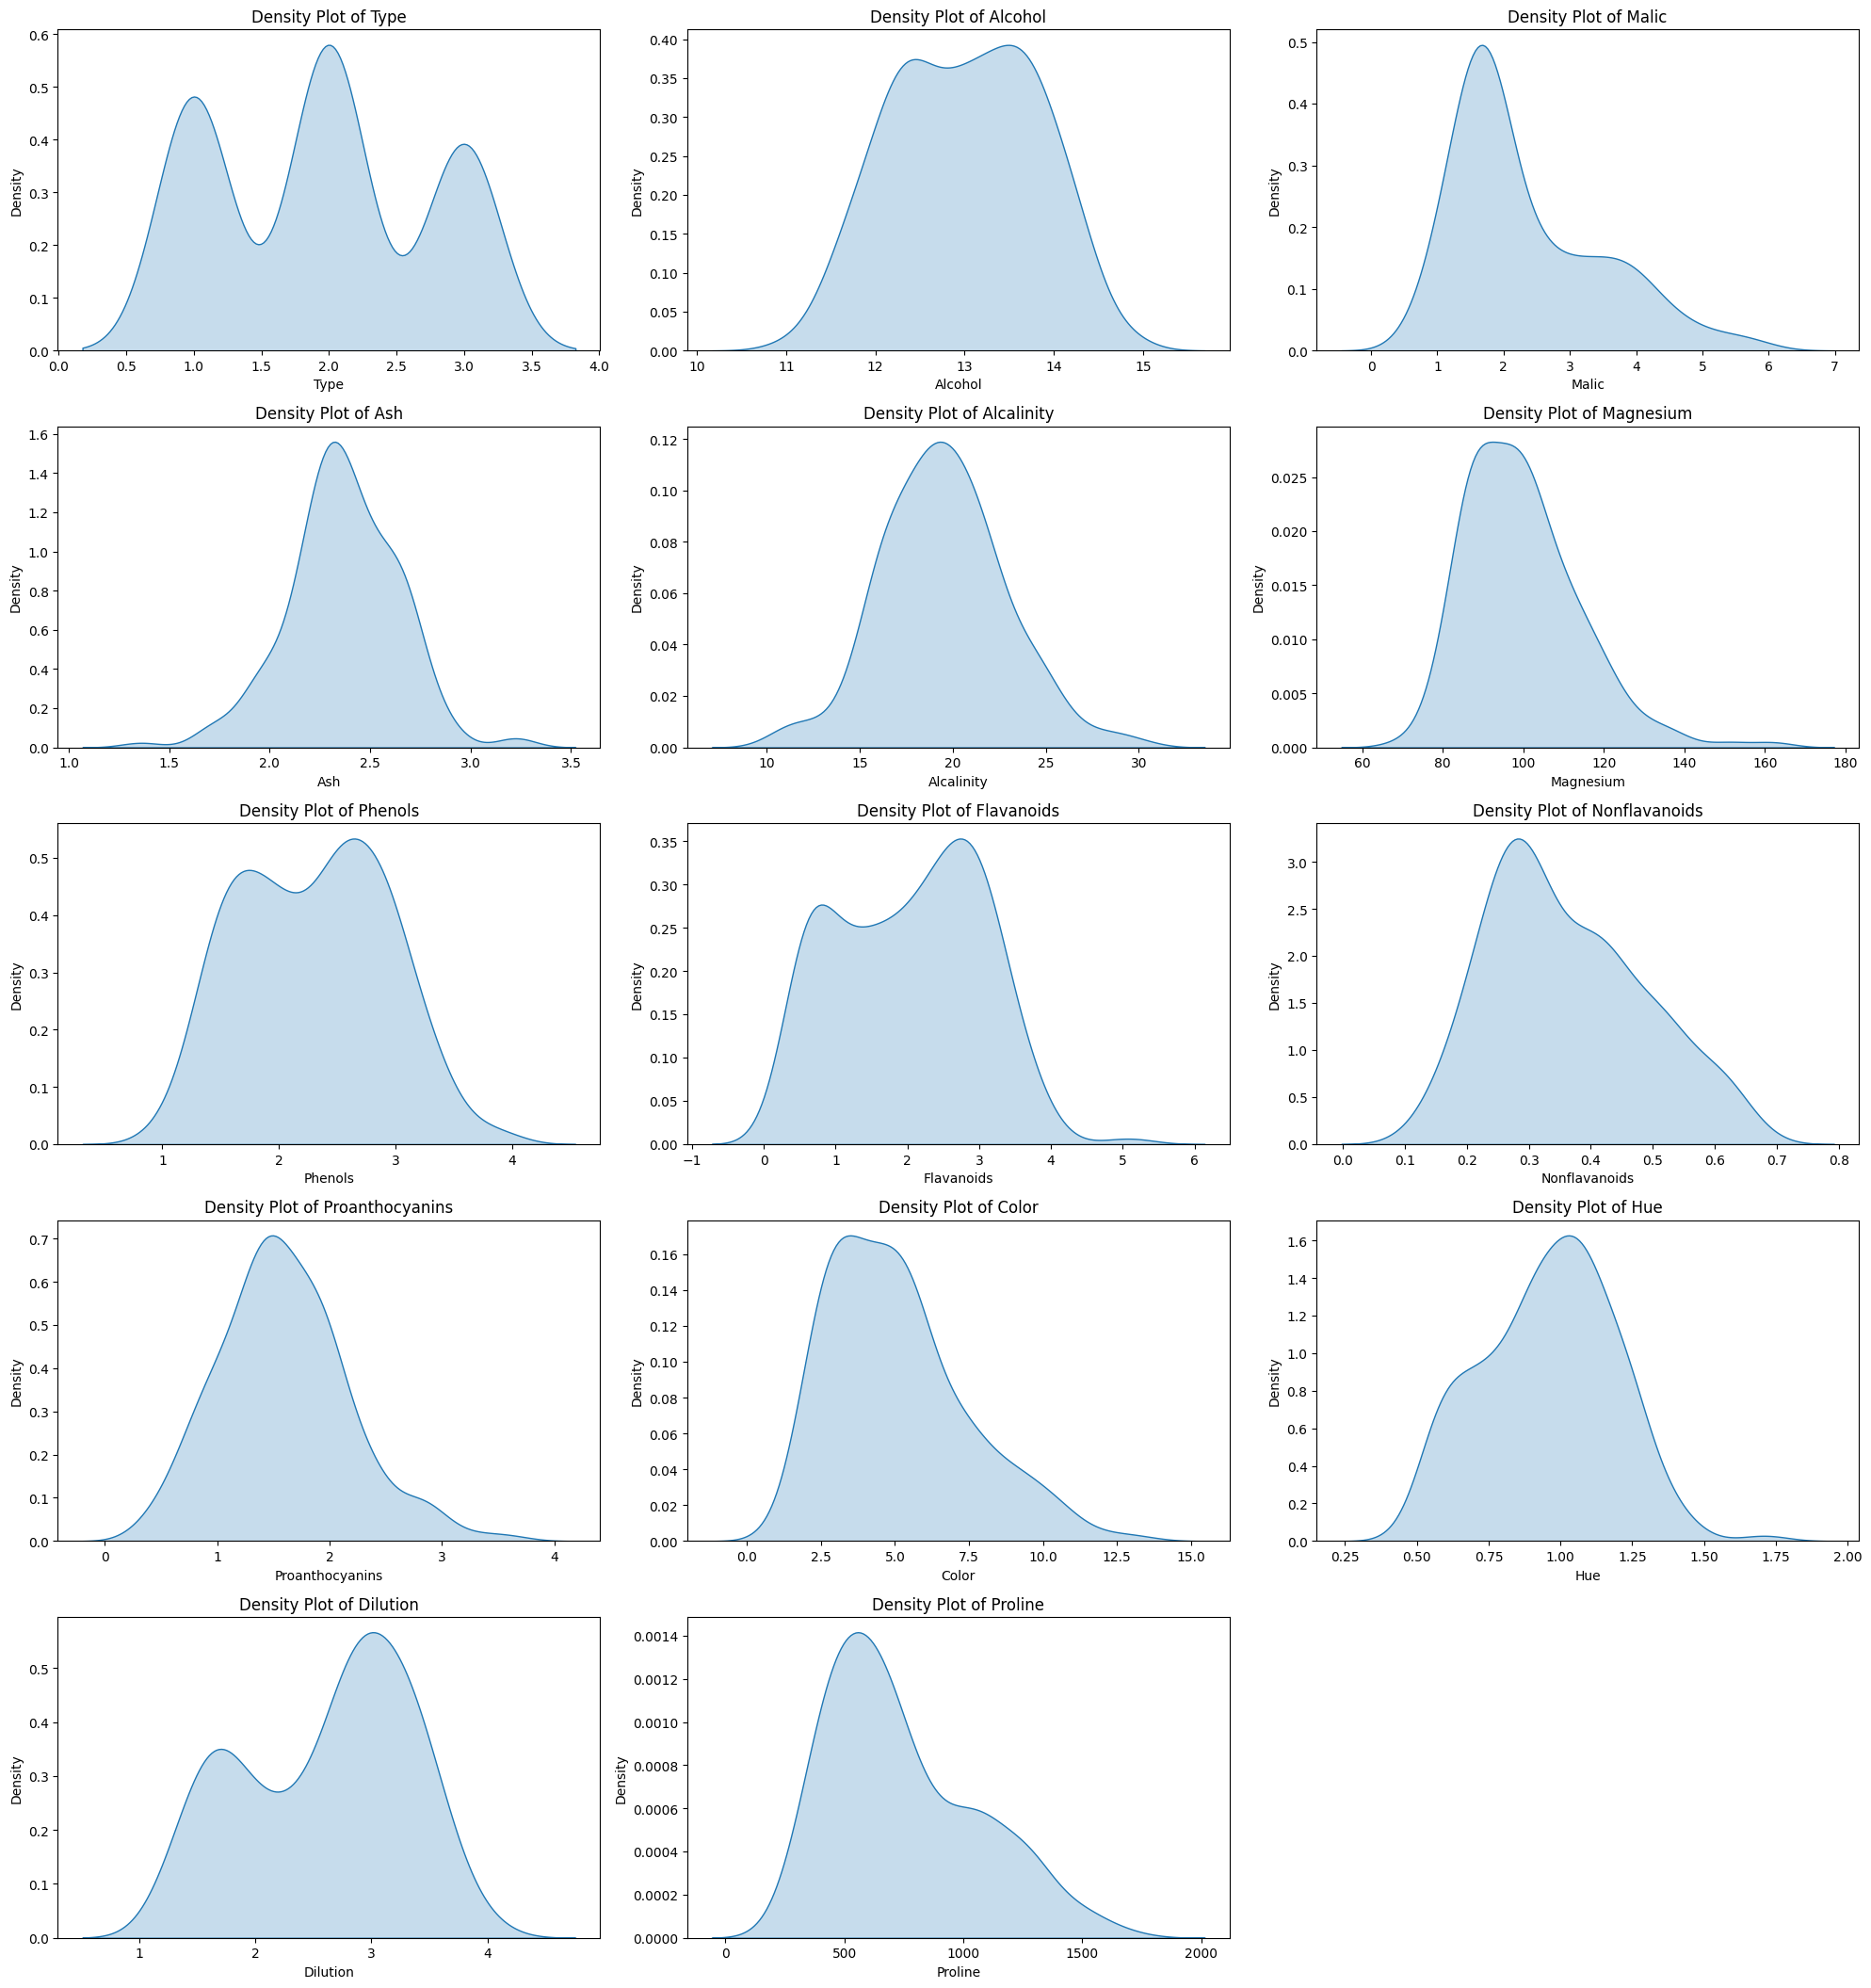

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns
plt.figure(figsize=(20, 25))
for i, column in enumerate(num_cols):
    plt.subplot(6, 3, i + 1)
    sns.kdeplot(df[column], shade=True)
    plt.title(f'Density Plot of {column}')
    plt.xlabel(column)
    plt.ylabel('Density')
plt.tight_layout()
plt.show()

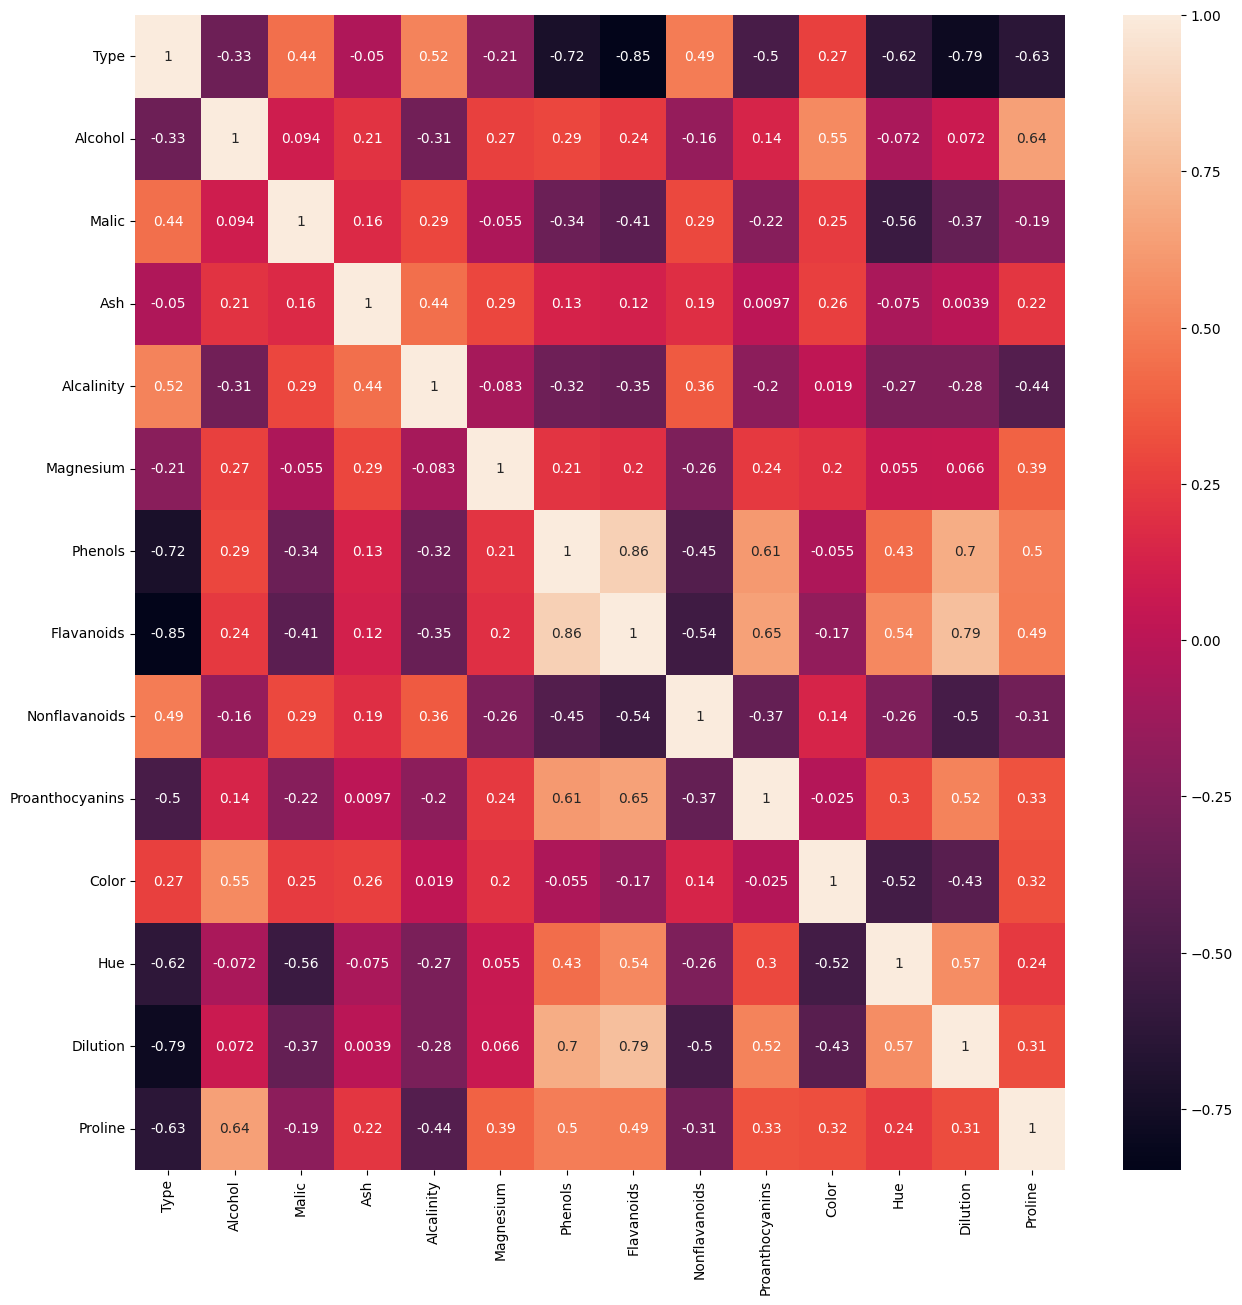

In [ ]:
fig, ax = plt.subplots(figsize=(15,15))
sns.heatmap(df.corr(), annot=True, ax=ax)
plt.show()

Inferences

*   The dataset contain 178 observations and 14 numerical features.
*   The target variable Type contains three classes (1, 2, and 3).
*   Proline, Magnesium, and Color have much larger numerical ranges than features such as Hue and Nonflavanoids
*   Phenols and Flavanoids have a very strong positive correlation (0.865).
*   Flavanoids and Dilution have a strong positive correlation (0.787).
*   Strong correlations indicate that some features contain related information and may contribute to multicollinearity in certain models.










# Dimensionality Reduction with PCA:

In [ ]:
#Standardize the features
from sklearn.preprocessing import StandardScaler
X = df.drop("Type", axis=1)
y = df["Type"]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
#Apply PCA
from sklearn.decomposition import PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

Explained variance ratio:
[0.36198848 0.1920749  0.11123631 0.0706903  0.06563294 0.04935823
 0.04238679 0.02680749 0.02222153 0.01930019 0.01736836 0.01298233
 0.00795215]


In [ ]:
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

print("Cumulative explained variance:")
print(cumulative_variance)

Cumulative explained variance:
[0.36198848 0.55406338 0.66529969 0.73598999 0.80162293 0.85098116
 0.89336795 0.92017544 0.94239698 0.96169717 0.97906553 0.99204785
 1.        ]


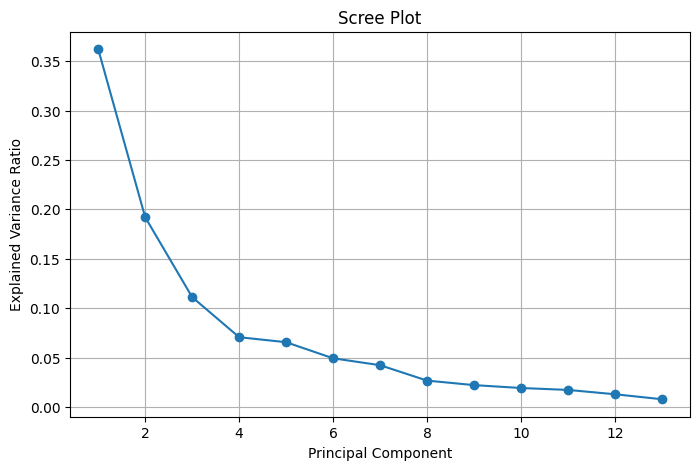

In [ ]:
#Scree plot
plt.figure(figsize=(8,5))
plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_,
    marker='o'
)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.grid()
plt.show()

In [ ]:
#Automatically find components explaining 95% variance
n_components = np.argmax(cumulative_variance >= 0.95) + 1

print("Number of components:", n_components)

Number of components: 10


In [ ]:
#Apply PCA with the selected number
pca_final = PCA(n_components=n_components)

X_pca = pca_final.fit_transform(X_scaled)

In [ ]:
print(X.shape)
print(X_pca.shape)

(178, 13)
(178, 10)


In [ ]:
print("Explained variance ratio:")
print(pca_final.explained_variance_ratio_)

print("Total explained variance:")
print(pca_final.explained_variance_ratio_.sum())

Explained variance ratio:
[0.36198848 0.1920749  0.11123631 0.0706903  0.06563294 0.04935823
 0.04238679 0.02680749 0.02222153 0.01930019]
Total explained variance:
0.9616971684450641


In [ ]:
#Create a DataFrame of principal components
pc_columns = [f"PC{i+1}" for i in range(n_components)]
X_pca_df = pd.DataFrame(
    X_pca,
    columns=pc_columns
)
X_pca_df["Type"] = y.values
print(X_pca_df.head())

        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0  3.316751  1.443463 -0.165739 -0.215631  0.693043  0.223880  0.596427   
1  2.209465 -0.333393 -2.026457 -0.291358 -0.257655  0.927120  0.053776   
2  2.516740  1.031151  0.982819  0.724902 -0.251033 -0.549276  0.424205   
3  3.757066  2.756372 -0.176192  0.567983 -0.311842 -0.114431 -0.383337   
4  1.008908  0.869831  2.026688 -0.409766  0.298458  0.406520  0.444074   

        PC8       PC9      PC10  Type  
0 -0.065139 -0.641443  1.020956     1  
1 -1.024416  0.308847  0.159701     1  
2  0.344216  1.177834  0.113361     1  
3 -0.643593 -0.052544  0.239413     1  
4 -0.416700 -0.326819 -0.078366     1  


# Clustering with Original Data:

In [ ]:
#Apply K-Means to original dataset
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
print(clusters)

[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0 1 0 0 0 0 0 0 0 0 0 0 0 2
 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 0 0 2 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


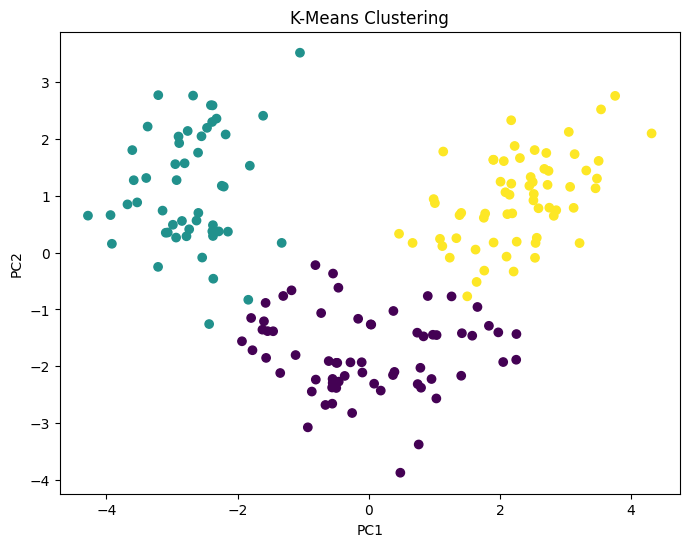

In [ ]:
#Visualize the clusters
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clustering")
plt.show()

In [ ]:
#Calculate Silhouette Score
from sklearn.metrics import silhouette_score
sil_score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", sil_score)

Silhouette Score: 0.2848589191898987


In [ ]:
#Calculate Davies–Bouldin Index
from sklearn.metrics import davies_bouldin_score
db_score = davies_bouldin_score(X_scaled, clusters)
print("Davies-Bouldin Index:", db_score)

Davies-Bouldin Index: 1.3891879777181648


# Clustering with PCA Data:

In [ ]:
#Apply K-Means to PCA-transformed data
kmeans_pca = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)
clusters_pca = kmeans_pca.fit_predict(X_pca)

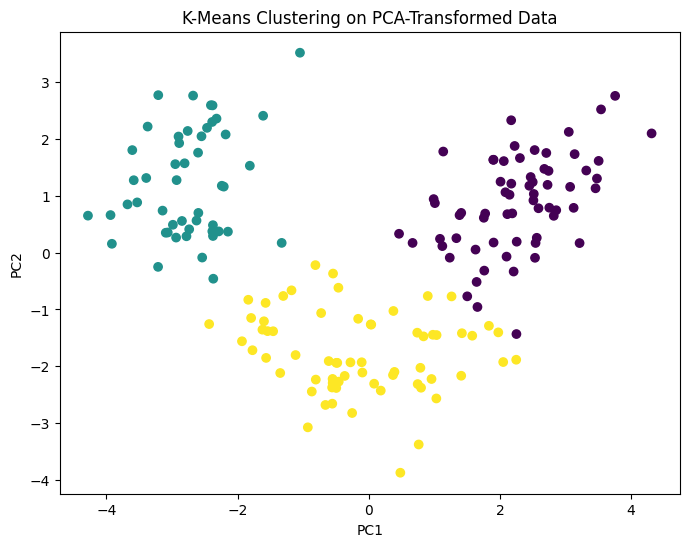

In [ ]:
#Visualize PCA clustering
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters_pca
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clustering on PCA-Transformed Data")
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score
silhouette_pca = silhouette_score(X_pca, clusters_pca)
print("PCA Silhouette Score:", silhouette_pca)

PCA Silhouette Score: 0.5610505693103248


In [ ]:
from sklearn.metrics import davies_bouldin_score
db_pca = davies_bouldin_score(X_pca, clusters_pca)
print("PCA Davies-Bouldin Index:", db_pca)

PCA Davies-Bouldin Index: 0.5972661544221362


In [ ]:
silhouette_original = silhouette_score(X_scaled, clusters)
db_original = davies_bouldin_score(X_scaled, clusters)

In [ ]:
comparison = pd.DataFrame({
    "Dataset": ["Original", "PCA"],
    "Silhouette Score": [
        silhouette_original,
        silhouette_pca
    ],
    "Davies-Bouldin Index": [
        db_original,
        db_pca
    ]
})
print(comparison)

    Dataset  Silhouette Score  Davies-Bouldin Index
0  Original          0.284859              1.389188
1       PCA          0.561051              0.597266


K-Means clustering on the PCA-transformed dataset performed significantly better than clustering on the original dataset. The Silhouette Score increased from 0.2849 to 0.5611, while the Davies-Bouldin Index decreased from 1.3892 to 0.5973. This indicates that PCA effectively reduced redundant information and improved the separation and compactness of the clusters. Therefore, the PCA-transformed dataset provides better clustering performance for the Wine dataset.

# Comparison and Analysis:

Comparison

*   Silhouette Score: increased from 0.285 → 0.561. Higher is better. This indicates that the PCA clusters are much better separated.
*   Davies-Bouldin Index: decreased from 1.389 → 0.597. Lower is better. This
indicates that the PCA clusters are more compact and better separated.
*   The PCA-transformed dataset performed much better than the original dataset.
*   Therefore, the PCA clusters are more compact and better separated.





Similarities and differences


1.   Similarities


*   K-Means was used for both datasets.
*   Both datasets were divided into 3 clusters.
*   The same clustering evaluation metrics were used.




2.   Differences


*   Original data had 13 features, while PCA reduced it to 10 components.
*   PCA produced substantially better-separated clusters.
*   The original dataset had more feature redundancy, which may have affected clustering.





Impact of dimensionality reduction

*   PCA had a positive impact on clustering performance. By reducing the 13 original features to 10 principal components while retaining most of the important variance, PCA removed some redundant information and made the underlying cluster structure clearer. This resulted in a higher Silhouette Score and lower Davies-Bouldin Index.



Trade-offs between PCA and original data

*   PCA reduces the number of features, while the original dataset keeps all features.
*   PCA reduces redundancy and correlated information, while the original data may contain redundant features.
*   PCA can improve clustering performance, while the original data may produce weaker clustering.
*   PCA requires less computational time, while the original dataset may require more computation.
*   PCA makes visualization easier, while visualization with many original features is more difficult.
*   Original features are easy to interpret, while PCA components are combinations of features and are harder to interpret.
*   PCA may lose some information, while the original dataset retains all the information.






# Conclusion and Insights:

Key Findings and Insights

*   The Wine dataset contains 13 numerical features and 3 wine classes.
*   There were no major missing-value issues in the dataset.
*   The features had different scales, so standardization was applied before PCA and clustering.
*   Correlation analysis showed that some features were strongly correlated, indicating redundant information.
*   PCA reduced the dimensionality from 13 features to 10 principal components while retaining most of the important variance.
*   K-Means clustering was performed with 3 clusters.
*   Clustering on the PCA-transformed data performed better.














Practical Implications of PCA and Clustering

*   PCA can reduce computational complexity and make high-dimensional data easier to visualize.
*   Clustering can identify natural groups in data without using predefined target labels.
*   K-Means can be useful for customer segmentation, grouping similar products, pattern discovery, and market analysis.







Recommendations
~~~
*   Use PCA when:

     *   There are many features.
     *   Features are highly correlated.
     *   Dimensionality needs to be reduced.
     *   Visualization or computational efficiency is important.

*   Use clustering when

     *   There is no target variable or labels are not required.
     *   You want to discover natural groups or pattern.
     *   You want to segment similar observations.

